In [ ]:
# Install Java (needed by Spark)
!apt-get install openjdk-11-jdk-headless -qq > /dev/null


In [ ]:
# Download Spark from verified archive link
!wget https://archive.apache.org/dist/spark/spark-3.5.1/spark-3.5.1-bin-hadoop3.tgz

--2025-05-01 08:17:38--  https://archive.apache.org/dist/spark/spark-3.5.1/spark-3.5.1-bin-hadoop3.tgz
Resolving archive.apache.org (archive.apache.org)... 65.108.204.189, 2a01:4f9:1a:a084::2
Connecting to archive.apache.org (archive.apache.org)|65.108.204.189|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 400446614 (382M) [application/x-gzip]
Saving to: ‘spark-3.5.1-bin-hadoop3.tgz.4’

spark-3.5.1-bin-had 100%[===================>] 381.90M  1.51MB/s    in 4m 15s  

2025-05-01 08:21:54 (1.50 MB/s) - ‘spark-3.5.1-bin-hadoop3.tgz.4’ saved [400446614/400446614]



In [ ]:
!ls -lh spark-3.5.1-bin-hadoop3.tgz.4


-rw-r--r-- 1 root root 382M Feb 15  2024 spark-3.5.1-bin-hadoop3.tgz.4


In [ ]:
!tar -xzf spark-3.5.1-bin-hadoop3.tgz.4
!mv spark-3.5.1-bin-hadoop3 spark


In [ ]:
!pip install -q pyspark==3.5.1 delta-spark findspark


In [ ]:
import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-11-openjdk-amd64"
os.environ["SPARK_HOME"] = "/content/spark"

import findspark
findspark.init()

from pyspark.sql import SparkSession
from delta import configure_spark_with_delta_pip

builder = SparkSession.builder \
    .appName("EV Data Pipeline") \
    .config("spark.sql.extensions", "io.delta.sql.DeltaSparkSessionExtension") \
    .config("spark.sql.catalog.spark_catalog", "org.apache.spark.sql.delta.catalog.DeltaCatalog")

spark = configure_spark_with_delta_pip(builder).getOrCreate()


In [ ]:
spark.range(5).show()


+---+
| id|
+---+
|  0|
|  1|
|  2|
|  3|
|  4|
+---+



In [ ]:
from google.colab import files
uploaded = files.upload()


Saving ElectricVehiclePopulationData.json to ElectricVehiclePopulationData.json


In [ ]:
import json

# Replace 'your_file.json' with actual filename
filename = list(uploaded.keys())[0]
# Load JSON data
with open(filename, 'r') as f:
    raw_data = json.load(f)


In [ ]:
# Extract column field names (machine-readable names)
columns = [col['fieldName'] for col in raw_data['meta']['view']['columns'] if not col['fieldName'].startswith(':')]

# Extract actual data rows
rows = raw_data['data']

# Truncate each row to match the number of columns (in case there are extra columns)
cleaned_rows = [row[8:8+len(columns)] for row in rows]


In [ ]:
import pandas as pd

# Create DataFrame
df = pd.DataFrame(cleaned_rows, columns=columns)

# Show first 5 rows
df.head()


,vin_1_10,county,city,state,zip_code,model_year,make,model,ev_type,cafv_type,electric_range,base_msrp,legislative_district,dol_vehicle_id,geocoded_column,electric_utility,_2020_census_tract
0,5YJ3E1EA8J,San Diego,Oceanside,CA,92051,2018,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,215,0,None,153998050,None,None,06073018509
1,3FA6P0PU7H,Sedgwick,Derby,KS,67037,2017,FORD,FUSION,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,21,0,None,138214331,POINT (-97.27013 37.54531),None,20173009801
2,1N4AZ0CP8D,Snohomish,Marysville,WA,98271,2013,NISSAN,LEAF,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,75,0,38,3129059,POINT (-122.19388 48.15353),PUGET SOUND ENERGY INC,53061052805
3,WBY8P8C58K,Kitsap,Bremerton,WA,98337,2019,BMW,I3,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,126,0,26,166525635,POINT (-122.62749 47.565),PUGET SOUND ENERGY INC,53035080500
4,5YJ3E1EA7K,Snohomish,Edmonds,WA,98026,2019,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,220,0,32,475248315,POINT (-122.31768 47.87166),PUGET SOUND ENERGY INC,53061050800


In [ ]:
df.to_csv('electric_vehicles.csv', index=False)
files.download('electric_vehicles.csv')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from pyspark.sql import Row

# Ensure 'df' is your Pandas DataFrame from earlier
row_data = [Row(**row._asdict()) for row in df.itertuples(index=False)]
spark_df = spark.createDataFrame(row_data)
spark_df.printSchema()
spark_df.show(3)


root
 |-- vin_1_10: string (nullable = true)
 |-- county: string (nullable = true)
 |-- city: string (nullable = true)
 |-- state: string (nullable = true)
 |-- zip_code: string (nullable = true)
 |-- model_year: string (nullable = true)
 |-- make: string (nullable = true)
 |-- model: string (nullable = true)
 |-- ev_type: string (nullable = true)
 |-- cafv_type: string (nullable = true)
 |-- electric_range: string (nullable = true)
 |-- base_msrp: string (nullable = true)
 |-- legislative_district: string (nullable = true)
 |-- dol_vehicle_id: string (nullable = true)
 |-- geocoded_column: string (nullable = true)
 |-- electric_utility: string (nullable = true)
 |-- _16: string (nullable = true)

+----------+---------+----------+-----+--------+----------+------+-------+--------------------+--------------------+--------------+---------+--------------------+--------------+--------------------+--------------------+-----------+
|  vin_1_10|   county|      city|state|zip_code|model_year|  

In [ ]:
# BRONZE LAYER — Raw Ingest
bronze_path = "/content/bronze_data"
spark_df.write.mode("overwrite").parquet(bronze_path)

# Read back to verify
bronze_df = spark.read.parquet(bronze_path)
bronze_df.show(3)


+----------+---------+----------+-----+--------+----------+------+-------+--------------------+--------------------+--------------+---------+--------------------+--------------+--------------------+--------------------+-----------+
|  vin_1_10|   county|      city|state|zip_code|model_year|  make|  model|             ev_type|           cafv_type|electric_range|base_msrp|legislative_district|dol_vehicle_id|     geocoded_column|    electric_utility|        _16|
+----------+---------+----------+-----+--------+----------+------+-------+--------------------+--------------------+--------------+---------+--------------------+--------------+--------------------+--------------------+-----------+
|5YJ3E1EA8J|San Diego| Oceanside|   CA|   92051|      2018| TESLA|MODEL 3|Battery Electric ...|Clean Alternative...|           215|        0|                NULL|     153998050|                NULL|                NULL|06073018509|
|3FA6P0PU7H| Sedgwick|     Derby|   KS|   67037|      2017|  FORD| FUSIO

In [ ]:
# SILVER LAYER — Clean & Data Quality Check
from pyspark.sql.functions import col

silver_df = bronze_df.dropDuplicates() \
    .filter(col("make").isNotNull()) \
    .filter(col("model").isNotNull()) \
    .filter(col("model_year").isNotNull()) \
    .filter((col("electric_range").cast("int").isNotNull()) & (col("electric_range") >= 0))

silver_path = "/content/silver_data"
silver_df.write.mode("overwrite").parquet(silver_path)

# Show cleaned data
silver_df.show(3)


+----------+---------+---------+-----+--------+----------+----------+--------------+--------------------+--------------------+--------------+---------+--------------------+--------------+--------------------+--------------------+-----------+
|  vin_1_10|   county|     city|state|zip_code|model_year|      make|         model|             ev_type|           cafv_type|electric_range|base_msrp|legislative_district|dol_vehicle_id|     geocoded_column|    electric_utility|        _16|
+----------+---------+---------+-----+--------+----------+----------+--------------+--------------------+--------------------+--------------+---------+--------------------+--------------+--------------------+--------------------+-----------+
|3FMTK3SS3P|     King|Sammamish|   WA|   98075|      2023|      FORD|MUSTANG MACH-E|Battery Electric ...|Eligibility unkno...|             0|        0|                  41|     225714205|POINT (-122.03539...|PUGET SOUND ENERG...|53033032224|
|WVGKMPE29M|Jefferson| Quilcene|

## Geographic Insights

In [ ]:
## Top 10 EV makers

silver_df.groupBy("make") \
    .count() \
    .orderBy("count", ascending=False) \
    .show(10)


+----------+-----+
|      make|count|
+----------+-----+
|     TESLA| 9917|
|    NISSAN| 2533|
| CHEVROLET| 2063|
|      FORD| 1177|
|       BMW|  988|
|       KIA|  902|
|    TOYOTA|  850|
|VOLKSWAGEN|  584|
|      AUDI|  467|
|     VOLVO|  440|
+----------+-----+
only showing top 10 rows



In [ ]:
## Find Underperforming EV Models (Low Average Range)

# Top 10 lowest average range models
avg_range_model.orderBy("avg_range").show(10)



+-------------+---------+
|        model|avg_range|
+-------------+---------+
|          EDV|      0.0|
|         XC40|      0.0|
| RS E-TRON GT|      0.0|
|      IONIQ 5|      0.0|
|          C40|      0.0|
|    EQB-CLASS|      0.0|
|         GV60|      0.0|
|          R1S|      0.0|
|EQS-CLASS SUV|      0.0|
|         ID.4|      0.0|
+-------------+---------+
only showing top 10 rows



In [ ]:
# Top 10 Cities with Most EVs

city_counts = silver_df.groupBy("city") \
    .count() \
    .orderBy("count", ascending=False)

city_counts.show(10)

+---------+-----+
|     city|count|
+---------+-----+
|  Seattle| 3983|
| Bellevue| 1258|
|  Redmond|  863|
|Vancouver|  789|
|  Olympia|  693|
| Kirkland|  684|
|  Bothell|  665|
|Sammamish|  628|
|   Renton|  569|
|   Tacoma|  453|
+---------+-----+
only showing top 10 rows



In [ ]:
## Top 10 Counties with Most EVs

county_counts = silver_df.groupBy("county") \
    .count() \
    .orderBy("count", ascending=False)

county_counts.show(10)


+---------+-----+
|   county|count|
+---------+-----+
|     King|11603|
|Snohomish| 2408|
|   Pierce| 1618|
|    Clark| 1301|
| Thurston| 1087|
|   Kitsap|  762|
|  Whatcom|  568|
|  Spokane|  508|
|   Benton|  248|
|   Skagit|  246|
+---------+-----+
only showing top 10 rows



In [ ]:
## EV Distribution by State
state_counts = silver_df.groupBy("state") \
    .count() \
    .orderBy("count", ascending=False)

state_counts.show(10)


+-----+-----+
|state|count|
+-----+-----+
|   WA|22088|
|   VA|   17|
|   CA|   14|
|   TX|    8|
|   MD|    5|
|   IL|    3|
|   NC|    2|
|   DC|    2|
|   NV|    2|
|   CT|    1|
+-----+-----+
only showing top 10 rows



In [ ]:
## Electric Utility Usage Analysis

utility_counts = silver_df.groupBy("electric_utility") \
    .count() \
    .orderBy("count", ascending=False)

utility_counts.show(10)


+--------------------+-----+
|    electric_utility|count|
+--------------------+-----+
|PUGET SOUND ENERG...| 7878|
|PUGET SOUND ENERG...| 4582|
|CITY OF SEATTLE -...| 4216|
|BONNEVILLE POWER ...| 1262|
|BONNEVILLE POWER ...|  976|
|PUGET SOUND ENERG...|  542|
|BONNEVILLE POWER ...|  313|
|BONNEVILLE POWER ...|  195|
|          PACIFICORP|  162|
|BONNEVILLE POWER ...|  134|
+--------------------+-----+
only showing top 10 rows



**Diagnostic Insights**

In [ ]:

## Average Electric Range per Manufacturer (Make)

from pyspark.sql.functions import col, avg

# Convert electric_range to numeric
silver_df = silver_df.withColumn("electric_range", col("electric_range").cast("int"))

# Average range by make
avg_range_make = silver_df.groupBy("make") \
    .agg(avg("electric_range").alias("avg_range")) \
    .orderBy("avg_range", ascending=False)

avg_range_make.show(10)


+---------+------------------+
|     make|         avg_range|
+---------+------------------+
|   JAGUAR|            204.75|
|    TESLA|  113.974992437229|
|CHEVROLET|112.93698497333979|
|    TH!NK|             100.0|
|   NISSAN| 88.66561389656533|
|     FIAT|             85.75|
|      KIA| 66.92682926829268|
|    SMART|62.705882352941174|
|     AUDI| 60.21841541755889|
|    HONDA| 46.77333333333333|
+---------+------------------+
only showing top 10 rows



In [ ]:
## Average Electric Range per Model
avg_range_model = silver_df.groupBy("model") \
    .agg(avg("electric_range").alias("avg_range")) \
    .orderBy("avg_range", ascending=False)

avg_range_model.show(10)


+--------+------------------+
|   model|         avg_range|
+--------+------------------+
|    KONA|             258.0|
|ROADSTER|237.85714285714286|
|  I-PACE|            204.75|
| MODEL S| 191.8760147601476|
| BOLT EV| 182.3937924345296|
| MODEL X|164.31479289940827|
| MODEL 3|             142.0|
|  E-TRON|129.85185185185185|
|  E-GOLF|108.97938144329896|
|    RAV4|             103.0|
+--------+------------------+
only showing top 10 rows



In [ ]:
## Average Electric Range by Vehicle Type
# Cast electric_range to integer
silver_df = silver_df.withColumn("electric_range", col("electric_range").cast("int"))


silver_df.groupBy("ev_type") \
    .avg("electric_range") \
    .orderBy("avg(electric_range)", ascending=False) \
    .show()

+--------------------+-------------------+
|             ev_type|avg(electric_range)|
+--------------------+-------------------+
|Battery Electric ...| 100.57828282828282|
|Plug-in Hybrid El...|  30.87780597306266|
+--------------------+-------------------+



In [ ]:
## Clean Alternative Fuel Vehicle (CAFV) Eligibility Rates

from pyspark.sql.functions import round

# Count and percentage
total = silver_df.count()

cafv_counts = silver_df.groupBy("cafv_type") \
    .count() \
    .withColumn("percentage", round((col("count") / total) * 100, 2))

cafv_counts.show(truncate=False)


+------------------------------------------------------------+-----+----------+
|cafv_type                                                   |count|percentage|
+------------------------------------------------------------+-----+----------+
|Eligibility unknown as battery range has not been researched|8123 |36.67     |
|Not eligible due to low battery range                       |2864 |12.93     |
|Clean Alternative Fuel Vehicle Eligible                     |11164|50.4      |
+------------------------------------------------------------+-----+----------+



Advanced Insights -

In [ ]:
### Market value estimation (vehicles × MSRP)

from pyspark.sql.functions import avg, col, count

# Convert MSRP to numeric
silver_df = silver_df.withColumn("base_msrp", col("base_msrp").cast("int"))

# Aggregate: count, avg MSRP, and estimated value
market_value_df = silver_df.groupBy("make") \
    .agg(
        count("*").alias("vehicle_count"),
        avg("base_msrp").alias("avg_msrp")
    ) \
    .withColumn("estimated_market_value", col("vehicle_count") * col("avg_msrp")) \
    .orderBy(col("estimated_market_value").desc())

market_value_df.show(10)


+--------+-------------+------------------+----------------------+
|    make|vehicle_count|          avg_msrp|estimated_market_value|
+--------+-------------+------------------+----------------------+
|   TESLA|         9917|2239.7347988302913|            2.221145E7|
|     BMW|          988| 4528.643724696356|             4474300.0|
|     KIA|          902| 4430.487804878048|    3996299.9999999995|
|   VOLVO|          440| 7558.977272727273|             3325950.0|
| PORSCHE|          163| 6515.337423312883|             1062000.0|
|    MINI|          124| 8027.419354838709|              995400.0|
|CHRYSLER|          309|2976.9741100323627|     919885.0000000001|
|  SUBARU|           23|16736.739130434784|              384945.0|
|  FISKER|            3|          102000.0|              306000.0|
|CADILLAC|           19|11857.105263157895|              225285.0|
+--------+-------------+------------------+----------------------+
only showing top 10 rows



In [ ]:
## Policy Impact: EV Adoption Before/After 2019
policy_df = silver_df.withColumn("model_year", col("model_year").cast("int"))

policy_df.groupBy("model_year") \
    .count() \
    .orderBy("model_year") \
    .show()

+----------+-----+
|model_year|count|
+----------+-----+
|      1999|    1|
|      2000|    2|
|      2008|    2|
|      2010|    5|
|      2011|  169|
|      2012|  335|
|      2013|  894|
|      2014|  666|
|      2015|  927|
|      2016| 1056|
|      2017| 1642|
|      2018| 2661|
|      2019| 2091|
|      2020| 2059|
|      2021| 3320|
|      2022| 4997|
|      2023| 1324|
+----------+-----+



In [ ]:
## Legislative District EV Count
silver_df.groupBy("legislative_district") \
    .count() \
    .orderBy("count", ascending=False) \
    .show(10)


+--------------------+-----+
|legislative_district|count|
+--------------------+-----+
|                  41| 1588|
|                  45| 1414|
|                  48| 1252|
|                  36| 1058|
|                  46|  971|
|                  43|  939|
|                   1|  937|
|                   5|  918|
|                  22|  802|
|                  34|  672|
+--------------------+-----+
only showing top 10 rows



In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


<ipython-input-65-fa0cf0b4d275>:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_makes_pd, x="make", y="count", palette="viridis")


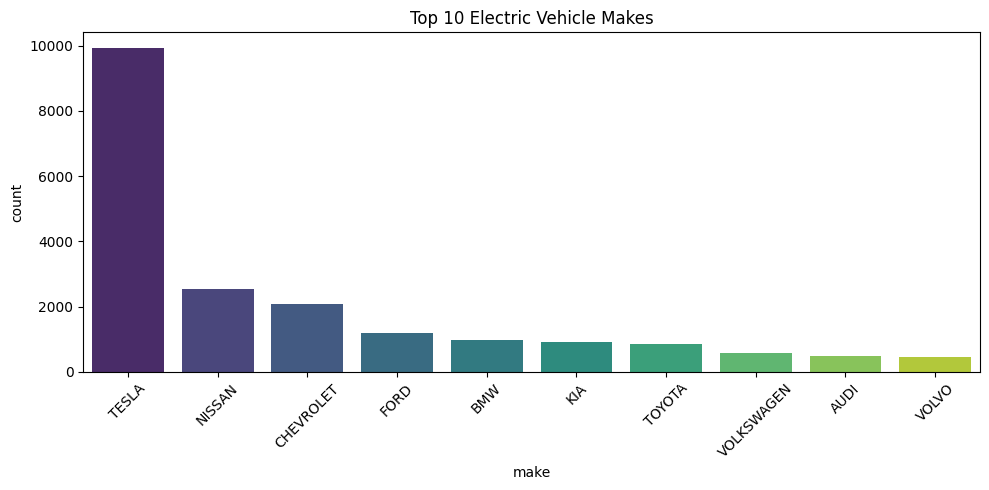

In [ ]:
### Top 10 EV Makes


top_makes_df = silver_df.groupBy("make").count().orderBy("count", ascending=False).limit(10)
top_makes_pd = top_makes_df.toPandas()

plt.figure(figsize=(10, 5))
sns.barplot(data=top_makes_pd, x="make", y="count", palette="viridis")
plt.title("Top 10 Electric Vehicle Makes")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


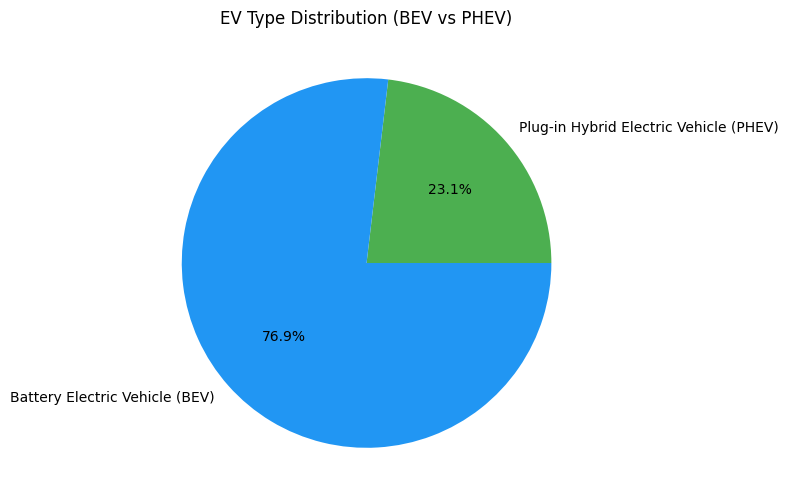

In [ ]:
## EV Type Distribution (BEV vs PHEV)


ev_type_df = silver_df.groupBy("ev_type").count().toPandas()

plt.figure(figsize=(6, 6))
plt.pie(ev_type_df["count"], labels=ev_type_df["ev_type"], autopct='%1.1f%%', colors=["#4CAF50", "#2196F3"])
plt.title("EV Type Distribution (BEV vs PHEV)")
plt.show()


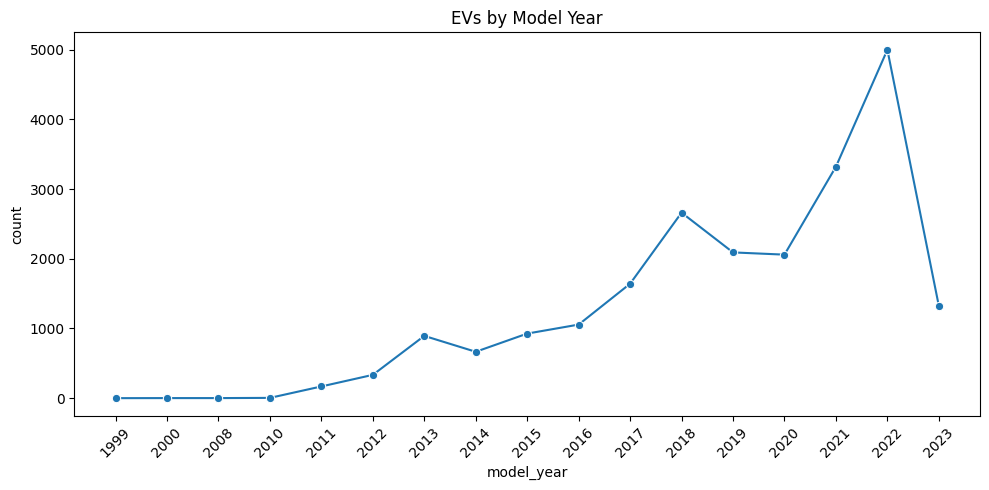

In [ ]:
## EV Adoption Over Time (Model Year)
year_df = silver_df.groupBy("model_year").count().orderBy("model_year").toPandas()
year_df = year_df.sort_values(by="model_year")

plt.figure(figsize=(10, 5))
sns.lineplot(data=year_df, x="model_year", y="count", marker="o")
plt.title("EVs by Model Year")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


<ipython-input-68-f75e089be90b>:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=range_df, x="ev_type", y="avg(electric_range)", palette="rocket")


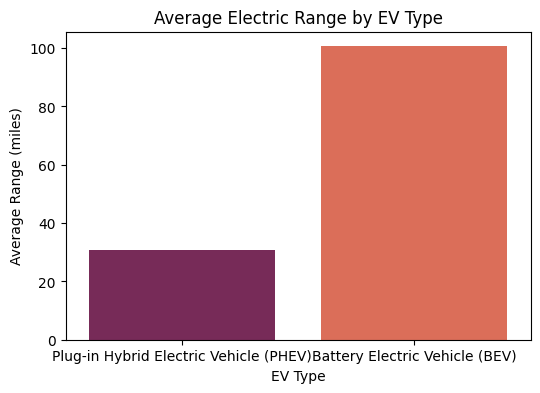

In [ ]:
### Average Electric Range by EV Type

from pyspark.sql.functions import col

silver_df = silver_df.withColumn("electric_range", col("electric_range").cast("int"))
range_df = silver_df.groupBy("ev_type").avg("electric_range").toPandas()

plt.figure(figsize=(6, 4))
sns.barplot(data=range_df, x="ev_type", y="avg(electric_range)", palette="rocket")
plt.title("Average Electric Range by EV Type")
plt.ylabel("Average Range (miles)")
plt.xlabel("EV Type")
plt.show()


<ipython-input-70-3c5f8d4ac54d>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=state_df, x="state", y="count", palette="mako")


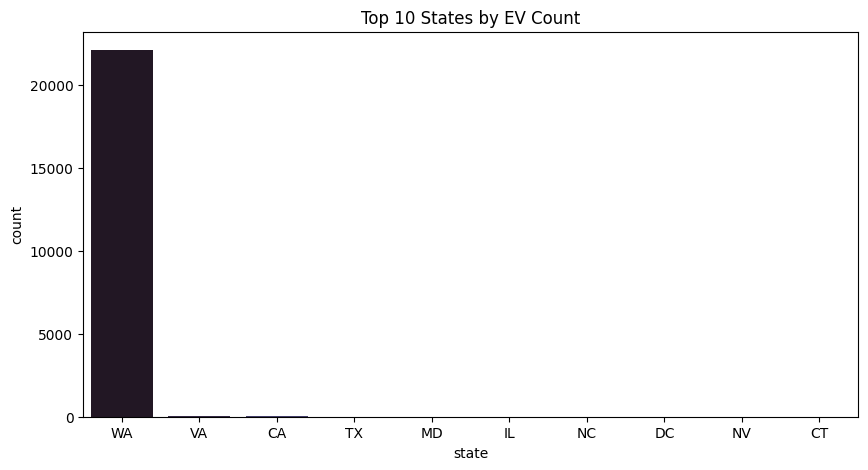

In [ ]:
## EVs by State
state_df = silver_df.groupBy("state").count().orderBy("count", ascending=False).limit(10).toPandas()

plt.figure(figsize=(10, 5))
sns.barplot(data=state_df, x="state", y="count", palette="mako")
plt.title("Top 10 States by EV Count")
plt.show()
